## 0. Setup & image download

In [ ]:
import os, urllib.request
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pywt

IMG_DIR = "images"
OUT_DIR = "outputs"
os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

def load(name, flags=cv2.IMREAD_COLOR):
    img = cv2.imread(os.path.join(IMG_DIR, name), flags)
    assert img is not None, f"{name} not found in {IMG_DIR}/"
    return img

def rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def show(imgs, titles=None, cols=2, figsize=(12, 6), cmap=None):
    if not isinstance(imgs, (list, tuple)): imgs = [imgs]
    rows = int(np.ceil(len(imgs) / cols))
    plt.figure(figsize=figsize)
    for i, im in enumerate(imgs):
        plt.subplot(rows, cols, i + 1)
        if im.ndim == 2: plt.imshow(im, cmap="gray")
        else:            plt.imshow(rgb(im))
        if titles: plt.title(titles[i])
        plt.axis("off")
    plt.tight_layout(); plt.show()

## Task 1 – Computer Screen Detection in a Computer Lab (Hough Line Transform)

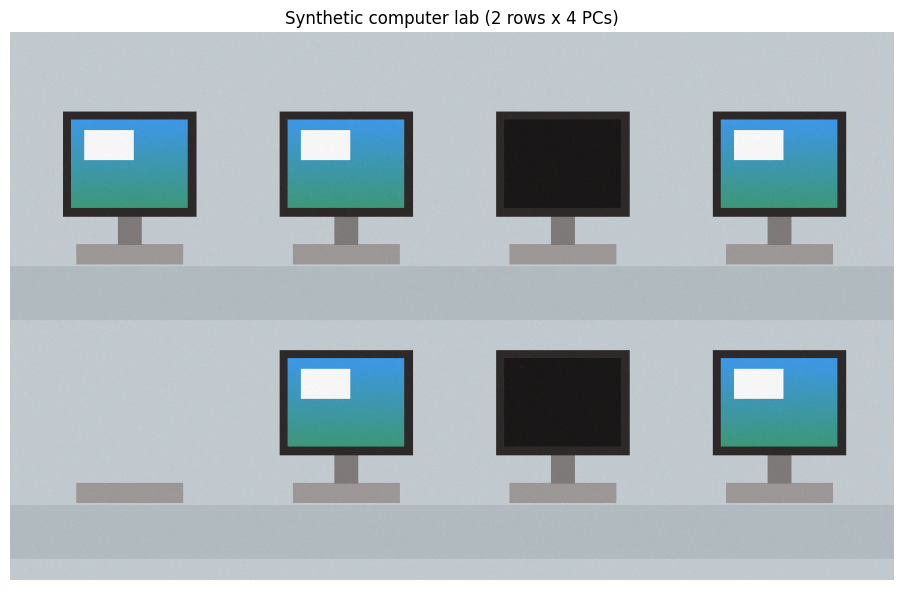

In [6]:
def make_lab_scene(seed=1):
    rng = np.random.default_rng(seed)
    H, W = 620, 1000
    img = np.full((H, W, 3), (205, 200, 192), np.uint8)  
    status = [["on", "on", "off", "on"],
              ["missing", "on", "off", "on"]]
    row_y = [90, 360]
    col_x = [60, 305, 550, 795]
    gt = []
    for r, y in enumerate(row_y):
        cv2.rectangle(img, (0, y + 175), (W, y + 235), (190, 185, 176), -1) 
        for c, x in enumerate(col_x):
            st = status[r][c]
            gt.append((r, c, st))
            cv2.rectangle(img, (x + 15, y + 150), (x + 135, y + 172), (150, 150, 155), -1)
            if st == "missing":
                continue
            cv2.rectangle(img, (x + 62, y + 118), (x + 88, y + 150), (120, 120, 125), -1)
            cv2.rectangle(img, (x, y), (x + 150, y + 118), (40, 40, 44), -1) 
            sx0, sy0, sx1, sy1 = x + 9, y + 9, x + 141, y + 109
            if st == "on":
                grad = np.linspace(230, 120, sy1 - sy0).astype(np.uint8)
                scr = np.zeros((sy1 - sy0, sx1 - sx0, 3), np.uint8)
                scr[..., 0] = grad[:, None]; scr[..., 1] = 150; scr[..., 2] = 60  
                img[sy0:sy1, sx0:sx1] = scr
                cv2.rectangle(img, (sx0 + 15, sy0 + 12), (sx0 + 70, sy0 + 45), (245, 245, 245), -1)
            else:
                img[sy0:sy1, sx0:sx1] = (22, 22, 24)
    img = cv2.add(img, rng.normal(0, 4, img.shape).astype(np.int16).clip(0, 255).astype(np.uint8))
    return img, gt

lab, gt = make_lab_scene()
cv2.imwrite(f"{OUT_DIR}/task1_lab_scene.png", lab)
show(lab, ["Synthetic computer lab (2 rows x 4 PCs)"], cols=1, figsize=(10, 6))

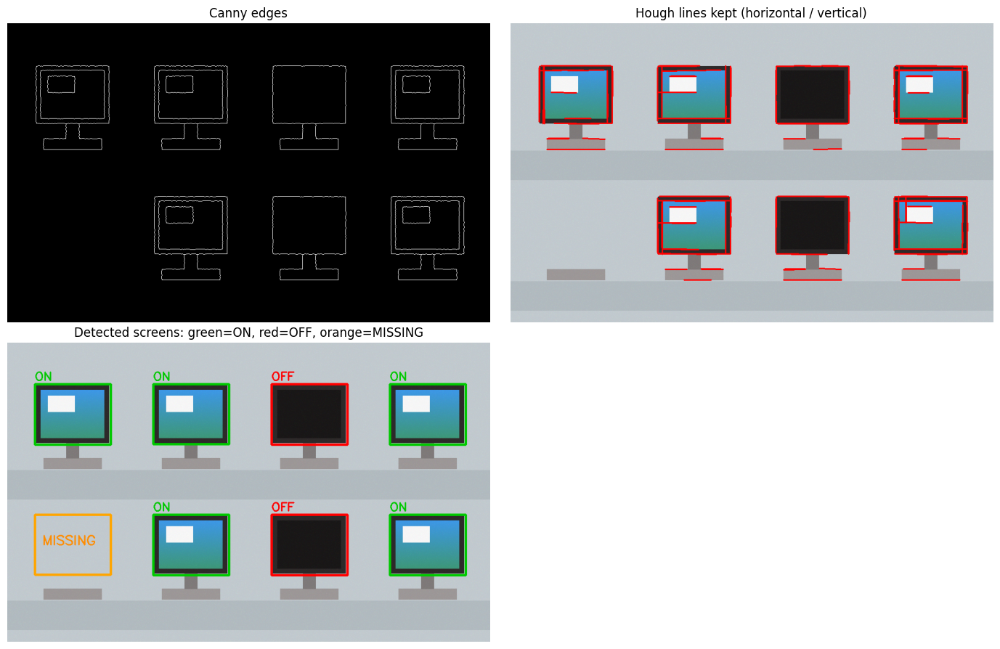

Detected screens : 7   ON: 5   OFF: 2   MISSING: 1
Ground truth     : {'on': 5, 'off': 2, 'missing': 1}


In [7]:
def detect_screens(img, on_thresh=70):
    gray  = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur  = cv2.GaussianBlur(gray, (5, 5), 1.2)
    edges = cv2.Canny(blur, 60, 160)

    mask = np.zeros_like(gray)
    kept = []
    for thr, min_len, gap in [(40, 60, 10), (25, 40, 15)]:
        lines = cv2.HoughLinesP(edges, rho=1, theta=np.pi/180, threshold=thr,
                                minLineLength=min_len, maxLineGap=gap)
        for x1, y1, x2, y2 in (lines[:, 0] if lines is not None else []):
            ang = abs(np.degrees(np.arctan2(y2 - y1, x2 - x1)))
            L   = np.hypot(x2 - x1, y2 - y1)
            horiz, vert = (ang < 5 or ang > 175), (85 < ang < 95)
            if (horiz or vert) and L < 220:            
                kept.append((x1, y1, x2, y2))
                cv2.line(mask, (x1, y1), (x2, y2), 255, 3)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((9, 9), np.uint8))
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    screens = []
    for c in cnts:
        x, y, w, h = cv2.boundingRect(c)
        if 110 <= w <= 190 and 80 <= h <= 150 and 1.1 < w / h < 1.7: 
            inner = gray[y + 12:y + h - 12, x + 12:x + w - 12]
            state = "ON" if inner.mean() > on_thresh else "OFF"
            screens.append(dict(box=(x, y, w, h), state=state, brightness=float(inner.mean())))
    return screens, edges, kept

def find_missing(screens, tol=60):
    def cluster(vals):
        vals = sorted(vals); groups = [[vals[0]]]
        for v in vals[1:]:
            if v - groups[-1][-1] < tol: groups[-1].append(v)
            else:                        groups.append([v])
        return [int(np.mean(g)) for g in groups]
    xs = cluster([s["box"][0] for s in screens]); ys = cluster([s["box"][1] for s in screens])
    w = int(np.mean([s["box"][2] for s in screens])); h = int(np.mean([s["box"][3] for s in screens]))
    missing = []
    for y in ys:
        for x in xs:
            if not any(abs(s["box"][0] - x) < tol and abs(s["box"][1] - y) < tol for s in screens):
                missing.append((x, y, w, h))
    return missing

screens, edges, kept = detect_screens(lab)
missing = find_missing(screens)

vis_lines = lab.copy()
for x1, y1, x2, y2 in kept: cv2.line(vis_lines, (x1, y1), (x2, y2), (0, 0, 255), 2)

result = lab.copy()
for s in screens:
    x, y, w, h = s["box"]; col = (0, 200, 0) if s["state"] == "ON" else (0, 0, 255)
    cv2.rectangle(result, (x, y), (x + w, y + h), col, 3)
    cv2.putText(result, s["state"], (x, y - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.8, col, 2)
for x, y, w, h in missing:
    cv2.rectangle(result, (x, y), (x + w, y + h), (0, 165, 255), 3)
    cv2.putText(result, "MISSING", (x + 15, y + h // 2), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 140, 255), 2)
cv2.imwrite(f"{OUT_DIR}/task1_result.png", result)

show([edges, vis_lines, result],
     ["Canny edges", "Hough lines kept (horizontal / vertical)", "Detected screens: green=ON, red=OFF, orange=MISSING"],
     cols=2, figsize=(14, 9))

print(f"Detected screens : {len(screens)}   ON: {sum(s['state']=='ON' for s in screens)}   "
      f"OFF: {sum(s['state']=='OFF' for s in screens)}   MISSING: {len(missing)}")
print("Ground truth     :", {k: sum(g[2] == k for g in gt) for k in ("on", "off", "missing")})

## Task 2 – Asset Tracking in a Computer Lab Using SIFT


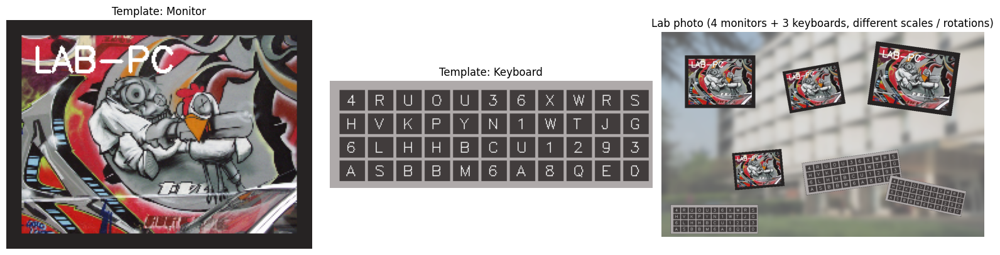

In [8]:
def make_templates():
    rng = np.random.default_rng(3)
    patch = cv2.resize(load("graf1.png"), (216, 156))
    mon = np.full((180, 240, 3), (35, 35, 38), np.uint8)
    mon[12:168, 12:228] = patch
    cv2.putText(mon, "LAB-PC", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 255), 2)
    kb = np.full((110, 330, 3), (170, 170, 175), np.uint8)
    letters = "QWERTYUIOPASDFGHJKLZXCVBNM1234567890"
    for r in range(4):
        for c in range(11):
            x, y = 10 + c * 29, 10 + r * 24
            cv2.rectangle(kb, (x, y), (x + 25, y + 20), (60, 60, 65), -1)
            cv2.putText(kb, letters[rng.integers(len(letters))], (x + 6, y + 15),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (240, 240, 240), 1)
    return {"Monitor": mon, "Keyboard": kb}

def paste(scene, tpl, center, scale, angle):
    h, w = tpl.shape[:2]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, scale)
    M[:, 2] += np.array(center) - np.array([w / 2, h / 2])
    warped = cv2.warpAffine(tpl, M, scene.shape[1::-1])
    m = cv2.warpAffine(np.full((h, w), 255, np.uint8), M, scene.shape[1::-1])
    scene[m > 0] = warped[m > 0]

def make_asset_scene():
    bg = cv2.resize(load("building.jpg"), (1100, 700))
    bg = cv2.addWeighted(cv2.GaussianBlur(bg, (0, 0), 9), 0.5, np.full_like(bg, 190), 0.5, 0)  # soft lab wall
    T = make_templates(); scene = bg.copy()
    for center, s, a in [((200, 170), 1.0, 0), ((520, 190), 0.8, 10), ((860, 160), 1.2, -8), ((330, 470), 0.7, 5)]:
        paste(scene, T["Monitor"], center, s, a)
    for center, s, a in [((650, 480), 1.0, 8), ((900, 560), 0.8, -12), ((180, 640), 0.9, 0)]:
        paste(scene, T["Keyboard"], center, s, a)
    return scene, T

asset_scene, templates = make_asset_scene()
cv2.imwrite(f"{OUT_DIR}/task2_templates_monitor.png", templates["Monitor"])
cv2.imwrite(f"{OUT_DIR}/task2_templates_keyboard.png", templates["Keyboard"])
show([templates["Monitor"], templates["Keyboard"], asset_scene],
     ["Template: Monitor", "Template: Keyboard", "Lab photo (4 monitors + 3 keyboards, different scales / rotations)"],
     cols=3, figsize=(16, 4))

Monitor  : template keypoints= 494 | instances found=4 | inliers=[468, 332, 236, 164]
Keyboard : template keypoints= 323 | instances found=3 | inliers=[78, 54, 34]


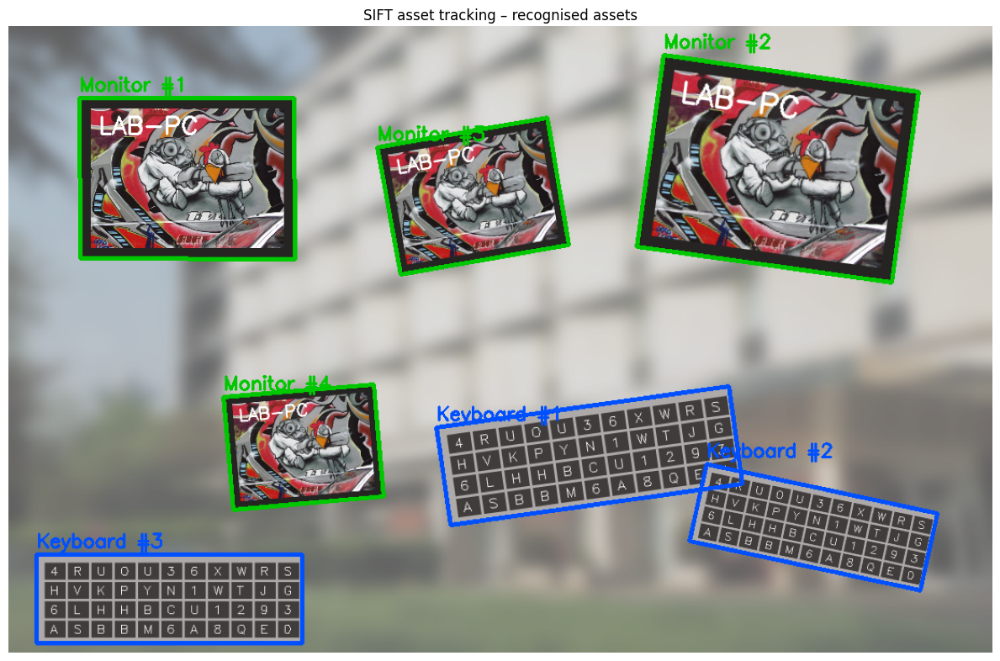


=== LAB INVENTORY ===
  Monitor  : 4
  Keyboard : 3


In [9]:
sift = cv2.SIFT_create()

def find_instances(tpl, scene, min_inliers=12, ratio=0.75, max_instances=15):
    g_t = cv2.cvtColor(tpl, cv2.COLOR_BGR2GRAY); g_s = cv2.cvtColor(scene, cv2.COLOR_BGR2GRAY)
    kp_t, des_t = sift.detectAndCompute(g_t, None)
    kp_s, des_s = sift.detectAndCompute(g_s, None)
    alive = np.ones(len(kp_s), bool)
    bf = cv2.BFMatcher(cv2.NORM_L2)
    h, w = g_t.shape
    corners = np.float32([[0, 0], [w, 0], [w, h], [0, h]]).reshape(-1, 1, 2)
    found = []
    for _ in range(max_instances):
        idx = np.where(alive)[0]
        if len(idx) < min_inliers: break
        knn = bf.knnMatch(des_s[idx], des_t, k=2)                    
        good = [(idx[m.queryIdx], m.trainIdx) for m, n in knn if m.distance < ratio * n.distance]
        if len(good) < min_inliers: break
        src = np.float32([kp_t[t].pt for _, t in good]).reshape(-1, 1, 2)
        dst = np.float32([kp_s[s].pt for s, _ in good]).reshape(-1, 1, 2)
        H, inl = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)
        if H is None or inl.sum() < min_inliers: break
        quad = cv2.perspectiveTransform(corners, H)
        if not cv2.isContourConvex(quad.astype(np.int32)): break
        found.append((quad, int(inl.sum())))
        for (s, _), ok in zip(good, inl.ravel()):                
            if ok: alive[s] = False
        for i in np.where(alive)[0]:                      
            if cv2.pointPolygonTest(quad.astype(np.float32), kp_s[i].pt, False) >= 0: alive[i] = False
    return found, (kp_t, kp_s)

colors = {"Monitor": (0, 200, 0), "Keyboard": (255, 80, 0)}
vis = asset_scene.copy(); inventory = {}
for name, tpl in templates.items():
    inst, (kp_t, kp_s) = find_instances(tpl, asset_scene)
    inventory[name] = len(inst)
    print(f"{name:9s}: template keypoints={len(kp_t):4d} | instances found={len(inst)} | inliers={[n for _, n in inst]}")
    for i, (quad, n) in enumerate(inst, 1):
        cv2.polylines(vis, [np.int32(quad)], True, colors[name], 4)
        p = np.int32(quad[0, 0])
        cv2.putText(vis, f"{name} #{i}", (p[0], max(p[1] - 8, 15)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, colors[name], 2)

cv2.imwrite(f"{OUT_DIR}/task2_inventory.png", vis)
show(vis, ["SIFT asset tracking – recognised assets"], cols=1, figsize=(12, 8))

print("\n=== LAB INVENTORY ===")
for k, v in inventory.items(): print(f"  {k:9s}: {v}")

## Task 3 – Anomaly Detection in Sensor Data Using Wavelet Transformation

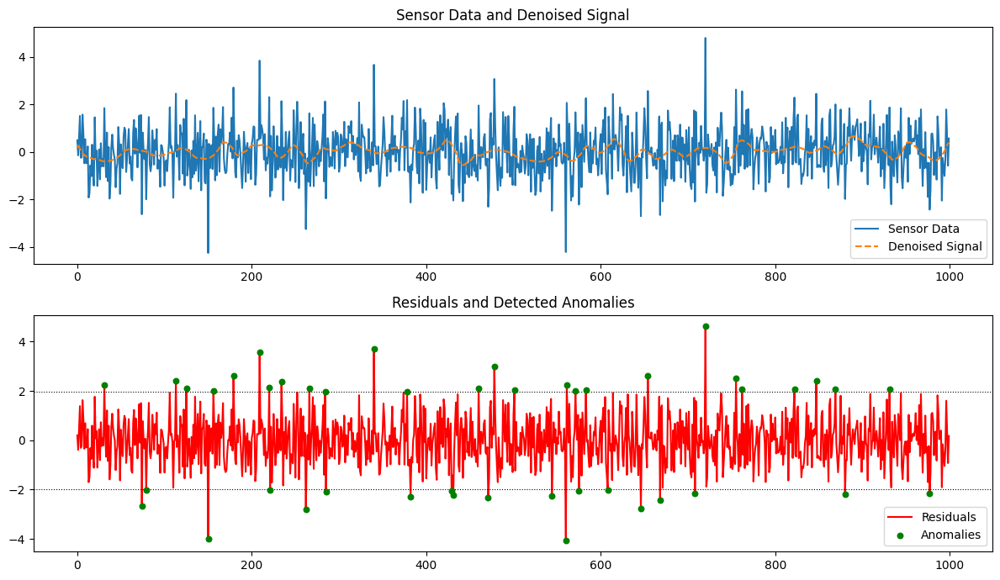

Threshold = ±1.97 | anomalies flagged: 45
Injected faults caught: 5/5 -> [150, 340, 560, 720, 880]


In [10]:
np.random.seed(42)
n = 1000
sensor = np.random.randn(n)           
injected = [150, 340, 560, 720, 880]   
sensor[injected] += np.random.choice([-1, 1], len(injected)) * 4.5

wavelet, level = "db4", 4
coeffs = pywt.wavedec(sensor, wavelet, level=level)
coeffs_den = [coeffs[0]] + [np.zeros_like(c) for c in coeffs[1:]]  
denoised = pywt.waverec(coeffs_den, wavelet)[:n]

residual = sensor - denoised
K = 2.0                               
thr = K * np.std(residual)
anom_idx = np.where(np.abs(residual) > thr)[0]

fig, ax = plt.subplots(2, 1, figsize=(12, 7))
ax[0].plot(sensor, label="Sensor Data"); ax[0].plot(denoised, "--", label="Denoised Signal")
ax[0].set_title("Sensor Data and Denoised Signal"); ax[0].legend(loc="lower right")
ax[1].plot(residual, "r", label="Residuals")
ax[1].scatter(anom_idx, residual[anom_idx], c="g", s=22, zorder=3, label="Anomalies")
ax[1].axhline(thr, color="k", ls=":", lw=0.8); ax[1].axhline(-thr, color="k", ls=":", lw=0.8)
ax[1].set_title("Residuals and Detected Anomalies"); ax[1].legend(loc="lower right")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/task3_wavelet_anomalies.png", dpi=120); plt.show()

caught = [i for i in injected if i in anom_idx]
print(f"Threshold = ±{thr:.2f} | anomalies flagged: {len(anom_idx)}")
print(f"Injected faults caught: {len(caught)}/{len(injected)} -> {caught}")

## Task 4 – Object Recognition (Using Video) with SIFT

In [11]:
VIDEO_IN = None               
test_video = f"{OUT_DIR}/task4_test_video.avi"
ref = load("box.png")

def make_object_video(path, n_frames=120, size=(640, 480)):
    W, H = size
    bg = cv2.resize(load("building.jpg"), size)
    h, w = ref.shape[:2]
    vw = cv2.VideoWriter(path, cv2.VideoWriter_fourcc(*"MJPG"), 30, size)
    for t in range(n_frames):
        u = t / (n_frames - 1)
        scale = 0.55 + 0.35 * np.sin(np.pi * u)      
        angle = -35 + 70 * u       
        cx = 150 + 340 * u; cy = 240 + 80 * np.sin(2 * np.pi * u)
        M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, scale)
        M[:, 2] += np.array([cx, cy]) - np.array([w / 2, h / 2])
        warped = cv2.warpAffine(ref, M, size)
        m = cv2.warpAffine(np.full((h, w), 255, np.uint8), M, size)
        f = bg.copy(); f[m > 0] = warped[m > 0]
        if 50 <= t < 70:            
            cv2.rectangle(f, (int(cx) - 160, int(cy) - 130), (int(cx) + 10, int(cy) - 40), (60, 60, 60), -1)
        f = cv2.GaussianBlur(f, (3, 3), 0.6)
        vw.write(f)
    vw.release()

if VIDEO_IN is None:
    make_object_video(test_video); VIDEO_IN = test_video
print("video:", VIDEO_IN)

video: outputs/task4_test_video.avi


Frames: 120 | object recognised in 120 (100%) | output video: outputs/task4_recognition_output.avi


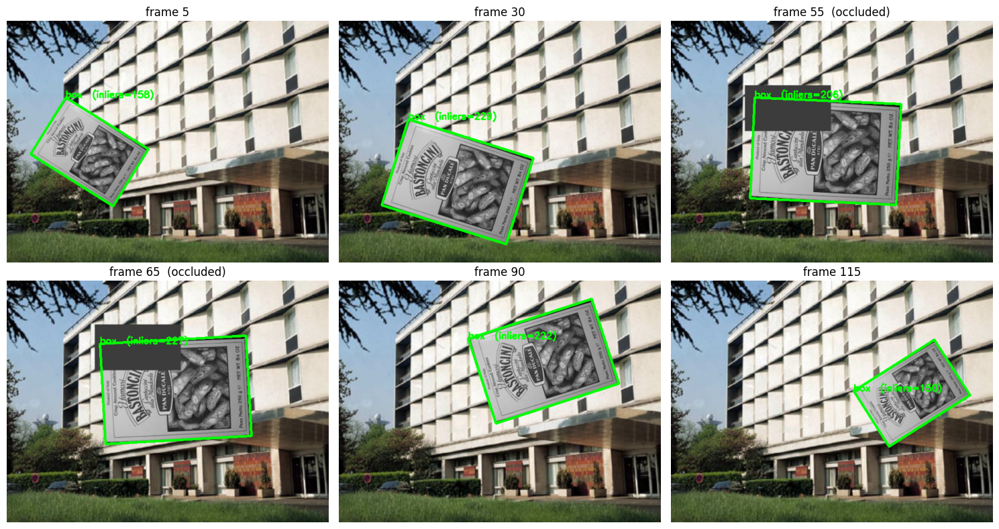

In [12]:
sift = cv2.SIFT_create()
gray_ref = cv2.cvtColor(ref, cv2.COLOR_BGR2GRAY)
kp_ref, des_ref = sift.detectAndCompute(gray_ref, None)
rh, rw = gray_ref.shape
ref_corners = np.float32([[0, 0], [rw, 0], [rw, rh], [0, rh]]).reshape(-1, 1, 2)
flann = cv2.FlannBasedMatcher(dict(algorithm=1, trees=5), dict(checks=50))

def recognise(frame, min_matches=10):
    g = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    kp, des = sift.detectAndCompute(g, None)
    if des is None or len(kp) < 2: return None, 0
    good = [m for m, n in flann.knnMatch(des_ref, des, k=2) if m.distance < 0.7 * n.distance]
    if len(good) < min_matches: return None, len(good)
    src = np.float32([kp_ref[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst = np.float32([kp[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
    H, inl = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)
    if H is None or inl.sum() < min_matches: return None, int(inl.sum()) if inl is not None else 0
    quad = cv2.perspectiveTransform(ref_corners, H)
    if not cv2.isContourConvex(np.int32(quad)) or cv2.contourArea(quad) < 400: return None, int(inl.sum())
    return quad, int(inl.sum())

cap = cv2.VideoCapture(VIDEO_IN)
fps = cap.get(cv2.CAP_PROP_FPS) or 30
size = (int(cap.get(3)), int(cap.get(4)))
out_path = f"{OUT_DIR}/task4_recognition_output.avi"
vw = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*"MJPG"), fps, size)
detected, samples, idx = 0, {}, 0
while True:
    ok, frame = cap.read()
    if not ok: break
    quad, n = recognise(frame)
    if quad is not None:
        detected += 1
        cv2.polylines(frame, [np.int32(quad)], True, (0, 255, 0), 3)
        cv2.putText(frame, f"box  (inliers={n})", tuple(np.int32(quad[0, 0])), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    else:
        cv2.putText(frame, "not found", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)
    if idx in (5, 30, 55, 65, 90, 115): samples[idx] = frame.copy()
    vw.write(frame); idx += 1
cap.release(); vw.release()

print(f"Frames: {idx} | object recognised in {detected} ({100 * detected / idx:.0f}%) | output video: {out_path}")
show(list(samples.values()), [f"frame {k}" + ("  (occluded)" if 50 <= k < 70 else "") for k in samples],
     cols=3, figsize=(15, 8))

## Task 5 – Panoramic Image Stitching with SIFT

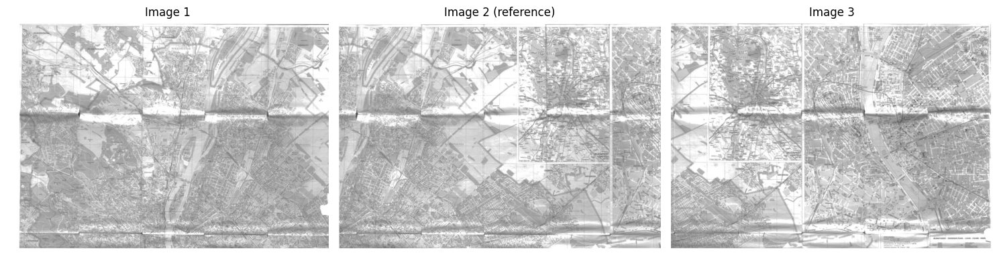

keypoints 4000/4000 | good matches 542 | RANSAC inliers 531
keypoints 4000/4000 | good matches 1178 | RANSAC inliers 1115


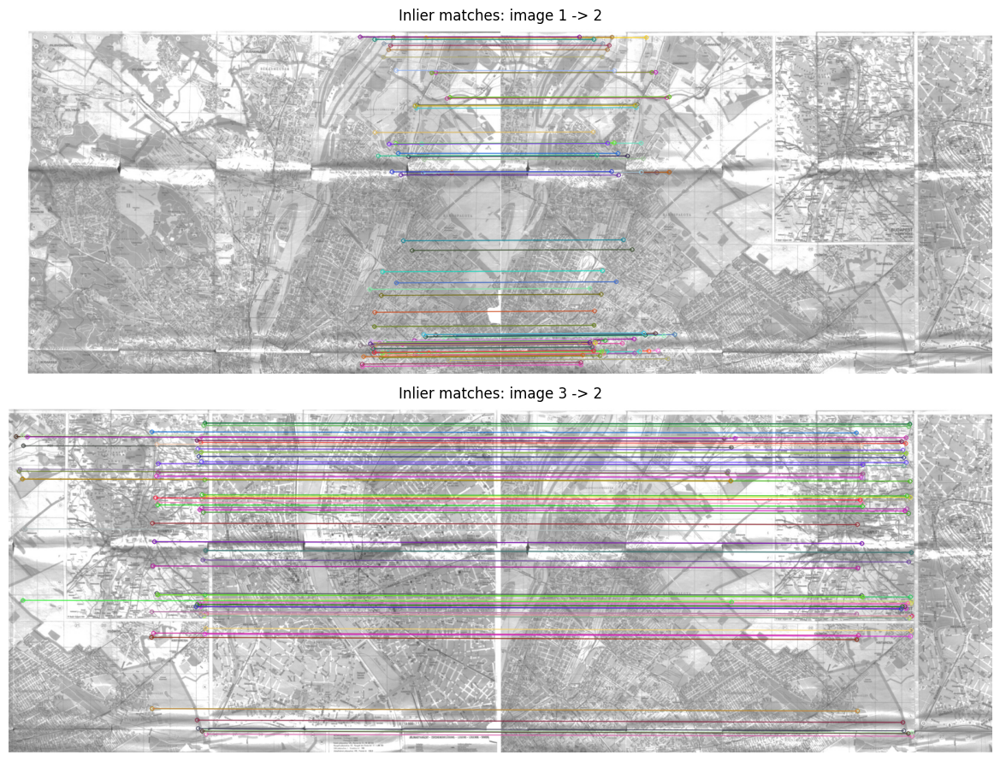

In [13]:
imgs = [load(f"budapest{i}.jpg") for i in (1, 2, 3)]
imgs = [cv2.resize(i, (800, int(i.shape[0] * 800 / i.shape[1]))) for i in imgs]
show(imgs, ["Image 1", "Image 2 (reference)", "Image 3"], cols=3, figsize=(15, 4))

sift = cv2.SIFT_create(nfeatures=4000)

def homography_to(src_img, dst_img, ratio=0.75, draw=False):
    g1, g2 = (cv2.cvtColor(i, cv2.COLOR_BGR2GRAY) for i in (src_img, dst_img))
    k1, d1 = sift.detectAndCompute(g1, None); k2, d2 = sift.detectAndCompute(g2, None)
    knn = cv2.BFMatcher(cv2.NORM_L2).knnMatch(d1, d2, k=2)
    good = [m for m, n in knn if m.distance < ratio * n.distance]
    src = np.float32([k1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst = np.float32([k2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
    H, inl = cv2.findHomography(src, dst, cv2.RANSAC, 4.0)
    print(f"keypoints {len(k1)}/{len(k2)} | good matches {len(good)} | RANSAC inliers {int(inl.sum())}")
    vis = None
    if draw:
        vis = cv2.drawMatches(src_img, k1, dst_img, k2, [m for m, ok in zip(good, inl.ravel()) if ok][:80],
                              None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    return H, vis

H12, m12 = homography_to(imgs[0], imgs[1], draw=True)
H32, m32 = homography_to(imgs[2], imgs[1], draw=True)
show([m12, m32], ["Inlier matches: image 1 -> 2", "Inlier matches: image 3 -> 2"], cols=1, figsize=(14, 9))

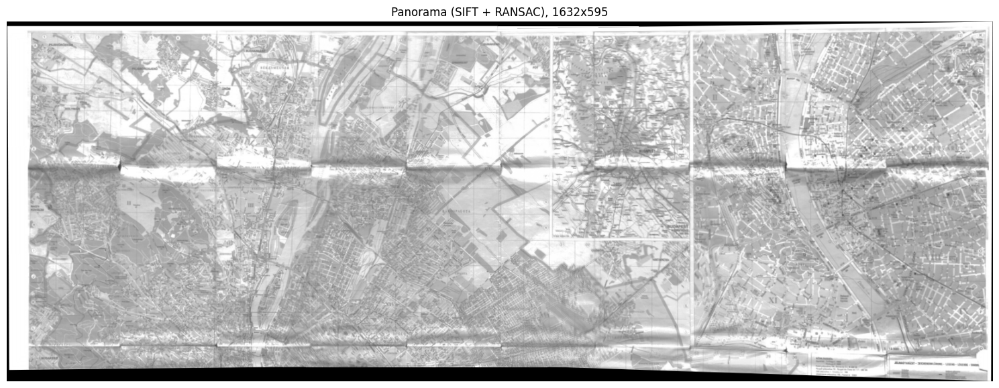

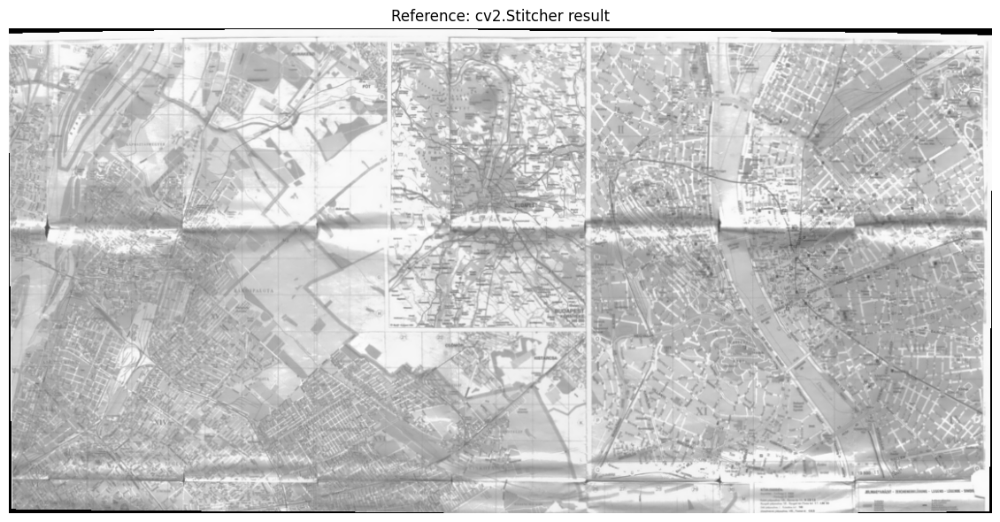

In [14]:
def stitch(imgs, Hs):
    pts = []
    for im, H in zip(imgs, Hs):
        h, w = im.shape[:2]
        c = np.float32([[0, 0], [w, 0], [w, h], [0, h]]).reshape(-1, 1, 2)
        pts.append(cv2.perspectiveTransform(c, H))
    pts = np.concatenate(pts)
    xmin, ymin = np.floor(pts.min(axis=(0, 1))).astype(int); xmax, ymax = np.ceil(pts.max(axis=(0, 1))).astype(int)
    T = np.array([[1, 0, -xmin], [0, 1, -ymin], [0, 0, 1]], np.float64)
    size = (xmax - xmin, ymax - ymin)
    acc = np.zeros((size[1], size[0], 3), np.float32); wsum = np.zeros((size[1], size[0]), np.float32)
    for im, H in zip(imgs, Hs):
        warped = cv2.warpPerspective(im, T @ H, size).astype(np.float32)
        mask = cv2.warpPerspective(np.full(im.shape[:2], 255, np.uint8), T @ H, size)
        w = cv2.distanceTransform((mask > 0).astype(np.uint8), cv2.DIST_L2, 3)
        acc += warped * w[..., None]; wsum += w
    pano = (acc / np.maximum(wsum, 1e-6)[..., None]).astype(np.uint8)
    ys, xs = np.where(wsum > 0)
    return pano[ys.min():ys.max() + 1, xs.min():xs.max() + 1]

pano = stitch(imgs, [H12, np.eye(3), H32])
cv2.imwrite(f"{OUT_DIR}/task5_panorama_sift.jpg", pano)
show(pano, [f"Panorama (SIFT + RANSAC), {pano.shape[1]}x{pano.shape[0]}"], cols=1, figsize=(15, 6))

status, pano_cv = cv2.Stitcher_create(cv2.Stitcher_PANORAMA).stitch(imgs)
if status == cv2.Stitcher_OK:
    cv2.imwrite(f"{OUT_DIR}/task5_panorama_opencv.jpg", pano_cv)
    show(pano_cv, ["Reference: cv2.Stitcher result"], cols=1, figsize=(15, 6))

## Task 6 – Lane Detection Using the Hough Line Transform

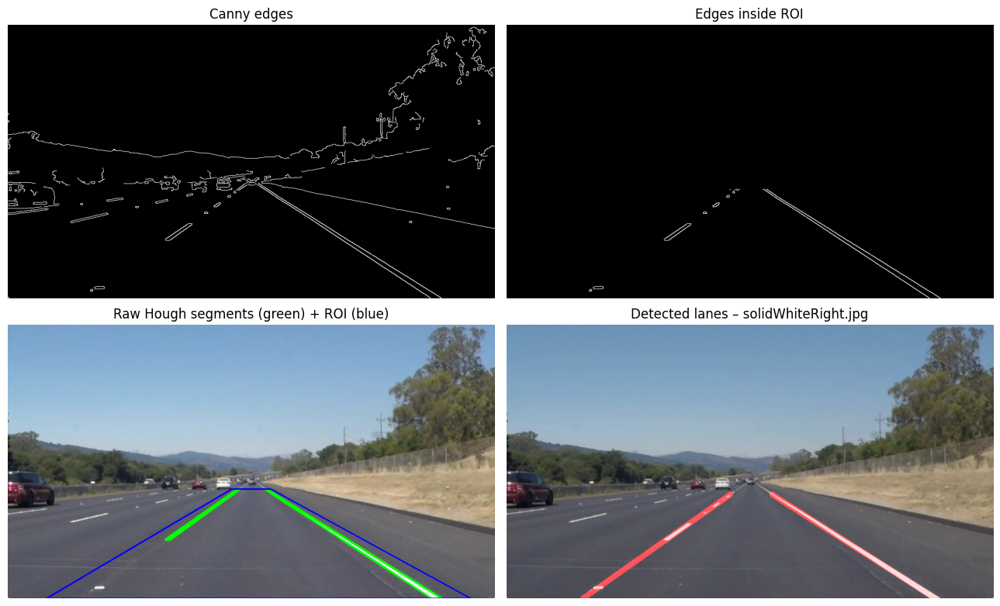

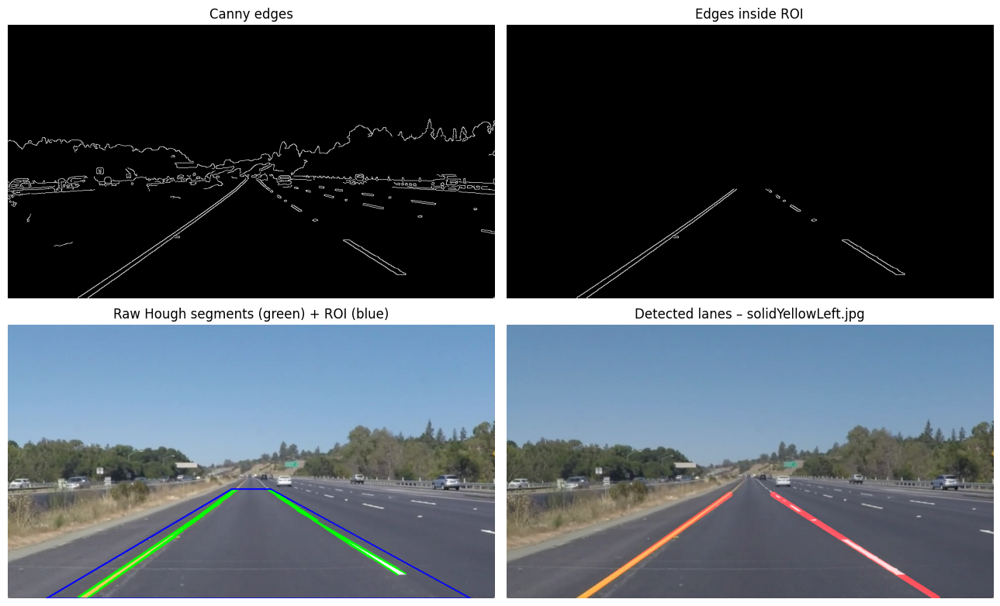

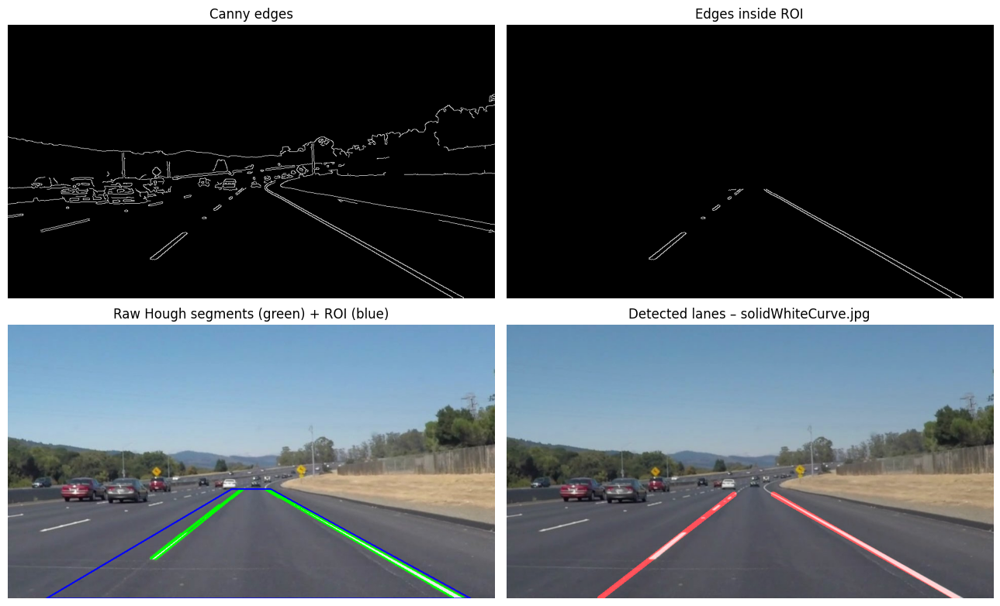

In [15]:
def detect_lanes(img):
    h, w = img.shape[:2]
    gray  = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur  = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blur, 50, 150)

    roi = np.zeros_like(edges)
    poly = np.array([[(int(0.08 * w), h), (int(0.46 * w), int(0.60 * h)),
                      (int(0.54 * w), int(0.60 * h)), (int(0.95 * w), h)]], np.int32)
    cv2.fillPoly(roi, poly, 255)
    masked = cv2.bitwise_and(edges, roi)

    lines = cv2.HoughLinesP(masked, 2, np.pi / 180, threshold=30, minLineLength=20, maxLineGap=100)

    left, right = [], []
    for x1, y1, x2, y2 in (lines[:, 0] if lines is not None else []):
        if x1 == x2: continue
        slope = (y2 - y1) / (x2 - x1)
        if abs(slope) < 0.4: continue      
        (left if slope < 0 else right).append((x1, y1, x2, y2))

    def fit(seg):
        if not seg: return None
        pts = np.array(seg)
        xs = np.r_[pts[:, 0], pts[:, 2]]; ys = np.r_[pts[:, 1], pts[:, 3]]
        m, b = np.polyfit(ys, xs, 1)        
        y_top, y_bot = int(0.62 * h), h
        return (int(m * y_bot + b), y_bot, int(m * y_top + b), y_top)

    layer = np.zeros_like(img)
    for ln in (fit(left), fit(right)):
        if ln: cv2.line(layer, ln[:2], ln[2:], (0, 0, 255), 10)
    result = cv2.addWeighted(img, 0.9, layer, 1.0, 0)
    raw = img.copy()
    for x1, y1, x2, y2 in (lines[:, 0] if lines is not None else []): cv2.line(raw, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.polylines(raw, poly, True, (255, 0, 0), 2)
    return edges, masked, raw, result

for name in ["solidWhiteRight.jpg", "solidYellowLeft.jpg", "solidWhiteCurve.jpg"]:
    img = load(name)
    edges, masked, raw, result = detect_lanes(img)
    cv2.imwrite(f"{OUT_DIR}/task6_lane_{name}", result)
    show([edges, masked, raw, result],
         ["Canny edges", "Edges inside ROI", "Raw Hough segments (green) + ROI (blue)", f"Detected lanes – {name}"],
         cols=2, figsize=(13, 8))

## Task 7 – Coin Detection and Counting (Hough Circle Transform)

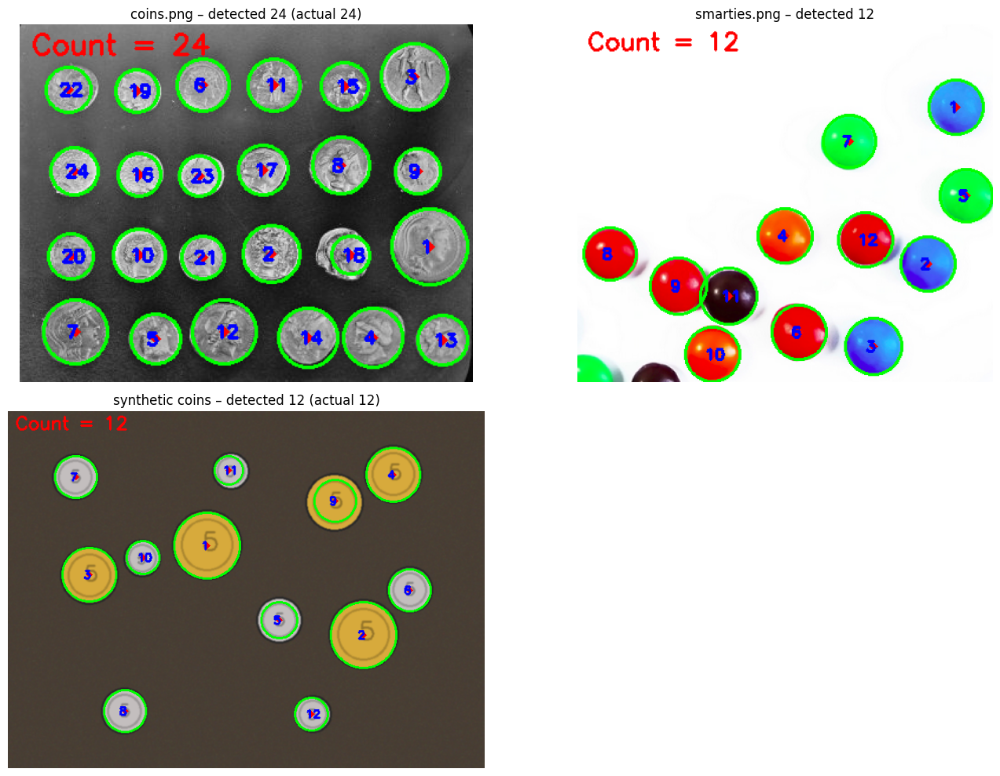

coins.png – detected 24 (actual 24)
smarties.png – detected 12
synthetic coins – detected 12 (actual 12)


In [16]:
def count_circles(img, dp=1.2, minDist=30, p1=100, p2=30, rmin=10, rmax=60, blur=7):
    gray = img if img.ndim == 2 else cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.medianBlur(gray, blur)
    c = cv2.HoughCircles(gray, cv2.HOUGH_GRADIENT, dp=dp, minDist=minDist,
                         param1=p1, param2=p2, minRadius=rmin, maxRadius=rmax)
    c = np.round(c[0]).astype(int) if c is not None else np.empty((0, 3), int)
    out = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR) if img.ndim == 2 else img.copy()
    for i, (x, y, r) in enumerate(c, 1):
        cv2.circle(out, (x, y), r, (0, 255, 0), 2); cv2.circle(out, (x, y), 2, (0, 0, 255), 3)
        cv2.putText(out, str(i), (x - 8, y + 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)
    cv2.putText(out, f"Count = {len(c)}", (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)
    return out, c

def synthetic_coins(n=12, seed=7):
    rng = np.random.default_rng(seed)
    img = np.full((480, 640, 3), (50, 60, 70), np.uint8)
    img = cv2.add(img, rng.normal(0, 6, img.shape).clip(0, 255).astype(np.uint8))
    placed = []
    while len(placed) < n:
        r = int(rng.choice([24, 30, 38, 46])); x, y = int(rng.integers(60, 580)), int(rng.integers(60, 420))
        if all(np.hypot(x - a, y - b) > r + rr + 10 for a, b, rr in placed): placed.append((x, y, r))
    for x, y, r in placed:
        col = (60, 170, 215) if r > 30 else (190, 190, 195)                 # gold-ish / silver
        cv2.circle(img, (x, y), r, col, -1)
        cv2.circle(img, (x, y), r, (40, 40, 40), 2)
        cv2.circle(img, (x, y), int(r * 0.75), tuple(int(c * 0.8) for c in col), 2)
        cv2.putText(img, "5", (x - 7, y + 7), cv2.FONT_HERSHEY_SIMPLEX, r / 40, tuple(int(c * 0.7) for c in col), 2)
    return cv2.GaussianBlur(img, (3, 3), 0.8), n

cases = []
if os.path.exists(os.path.join(IMG_DIR, "coins.png")):
    coins = load("coins.png")
    res, c = count_circles(coins, dp=1.2, minDist=30, p1=100, p2=30, rmin=15, rmax=40, blur=5)
    cases.append((res, f"coins.png – detected {len(c)} (actual 24)"))
sm = load("smarties.png")
res, c = count_circles(sm, dp=1, minDist=20, p1=100, p2=30, rmin=10, rmax=30, blur=5)
cases.append((res, f"smarties.png – detected {len(c)}"))
syn, true_n = synthetic_coins()
res, c = count_circles(syn, dp=1.2, minDist=40, p1=100, p2=35, rmin=18, rmax=55, blur=5)
cases.append((res, f"synthetic coins – detected {len(c)} (actual {true_n})"))

for i, (r_, t) in enumerate(cases): cv2.imwrite(f"{OUT_DIR}/task7_coins_{i}.png", r_)
show([r for r, _ in cases], [t for _, t in cases], cols=2, figsize=(14, 10))
for _, t in cases: print(t)

## Task 8 – Smart Security System (Boundary Detection + Alarm Zone)

🚨 ALARM triggered at frame 90
Processed 140 frames | frames in alarm: 51 | alarm events at frames: [90]


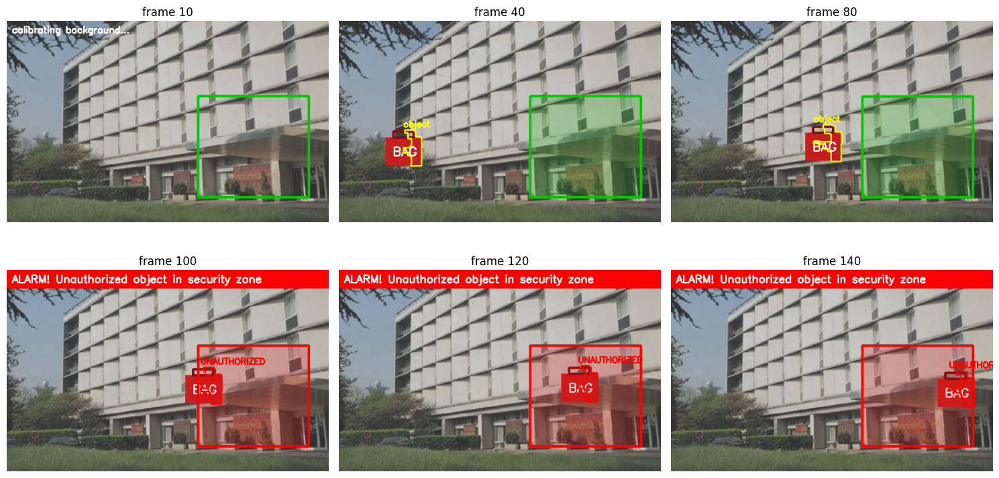

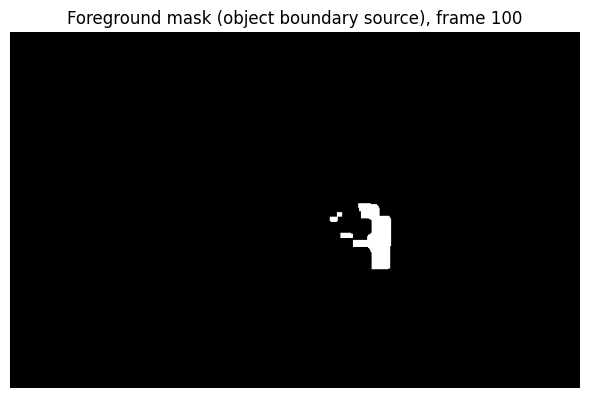

In [17]:
W, H = 640, 400
ZONE = np.array([[380, 150], [600, 150], [600, 350], [380, 350]], np.int32)   

def make_security_video(path, n_frames=140):
    bg = cv2.resize(load("building.jpg"), (W, H))
    bg = cv2.addWeighted(bg, 0.6, np.full_like(bg, 120), 0.4, 0)
    rng = np.random.default_rng(0)
    vw = cv2.VideoWriter(path, cv2.VideoWriter_fourcc(*"MJPG"), 25, (W, H))
    for t in range(n_frames):
        f = bg.copy()
        if t >= 20:                             
            u = (t - 20) / (n_frames - 21)
            x = int(10 + 520 * u); y = 220 + int(15 * np.sin(6 * u))
            cv2.rectangle(f, (x, y), (x + 70, y + 55), (30, 30, 200), -1)     
            cv2.rectangle(f, (x + 15, y - 12), (x + 55, y), (20, 20, 120), 4) 
            cv2.putText(f, "BAG", (x + 14, y + 36), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
        f = cv2.add(f, rng.normal(0, 3, f.shape).clip(0, 255).astype(np.uint8))
        vw.write(f)
    vw.release()

sec_video = f"{OUT_DIR}/task8_security_input.avi"
make_security_video(sec_video)

class SecuritySystem:
    def __init__(self, zone, min_area=800, overlap_px=150, warmup=15):
        self.zone, self.min_area, self.overlap_px, self.warmup = zone, min_area, overlap_px, warmup
        self.bg = cv2.createBackgroundSubtractorMOG2(history=100, varThreshold=40, detectShadows=False)
        self.zone_mask = None; self.alarm_on = False; self.events = []; self.frame_id = 0
        self.k = np.ones((5, 5), np.uint8)

    def process_frame(self, frame, learn=True):
        if self.zone_mask is None:
            self.zone_mask = np.zeros(frame.shape[:2], np.uint8); cv2.fillPoly(self.zone_mask, [self.zone], 255)
        self.frame_id += 1
        fg = self.bg.apply(cv2.GaussianBlur(frame, (5, 5), 0), learningRate=0.02 if learn else 0)
        fg = cv2.threshold(fg, 200, 255, cv2.THRESH_BINARY)[1]
        fg = cv2.morphologyEx(cv2.morphologyEx(fg, cv2.MORPH_OPEN, self.k), cv2.MORPH_CLOSE, self.k, iterations=2)

        if self.frame_id <= self.warmup:          
            out = frame.copy(); cv2.polylines(out, [self.zone], True, (0, 200, 0), 3)
            cv2.putText(out, 'calibrating background...', (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
            return out, fg, False
        cnts, _ = cv2.findContours(fg, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        out, intruder = frame.copy(), False
        for c in cnts:
            if cv2.contourArea(c) < self.min_area: continue
            obj = np.zeros_like(fg); cv2.drawContours(obj, [c], -1, 255, -1)
            inside = cv2.countNonZero(cv2.bitwise_and(obj, self.zone_mask)) > self.overlap_px
            col = (0, 0, 255) if inside else (0, 255, 255)
            cv2.drawContours(out, [c], -1, col, 2)        
            x, y, w, h = cv2.boundingRect(c)
            cv2.putText(out, "UNAUTHORIZED" if inside else "object", (x, y - 6), cv2.FONT_HERSHEY_SIMPLEX, 0.55, col, 2)
            intruder |= inside

        zone_col = (0, 0, 255) if intruder else (0, 200, 0)
        ov = out.copy(); cv2.fillPoly(ov, [self.zone], zone_col); out = cv2.addWeighted(ov, 0.18, out, 0.82, 0)
        cv2.polylines(out, [self.zone], True, zone_col, 3)
        if intruder:
            cv2.rectangle(out, (0, 0), (out.shape[1], 36), (0, 0, 255), -1)
            cv2.putText(out, "ALARM! Unauthorized object in security zone", (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
        if intruder and not self.alarm_on:                        
            self.events.append(self.frame_id); self.trigger_alarm()
        self.alarm_on = intruder
        return out, fg, intruder

    def trigger_alarm(self):
        print(f"\U0001F6A8 ALARM triggered at frame {self.frame_id}")       

sec = SecuritySystem(ZONE)
cap = cv2.VideoCapture(sec_video)
vw = cv2.VideoWriter(f"{OUT_DIR}/task8_security_output.avi", cv2.VideoWriter_fourcc(*"MJPG"), 25, (W, H))
samples, alarm_frames, i = {}, 0, 0
while True:
    ok, frame = cap.read()
    if not ok: break
    out, fg, alarm = sec.process_frame(frame)
    alarm_frames += alarm; vw.write(out); i += 1
    if i in (10, 40, 80, 100, 120, 140): samples[i] = (out, fg)
cap.release(); vw.release()
print(f"Processed {i} frames | frames in alarm: {alarm_frames} | alarm events at frames: {sec.events}")

imgs_, tit_ = [], []
for k, (o, m) in samples.items(): imgs_ += [o]; tit_ += [f"frame {k}"]
show(imgs_, tit_, cols=3, figsize=(15, 8))
show([samples[100][1]], ["Foreground mask (object boundary source), frame 100"], cols=1, figsize=(6, 4))
